In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("Walmart Data Analysis and Forcasting.csv")

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
print(df.shape)

df.info()

df.isnull().sum()

(6435, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,5,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,5,3,2010


In [ ]:
X = df[[
    "Store",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Day",
    "Month",
    "Year"
]]

y = df["Weekly_Sales"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5148, 9)
(1287, 9)


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[1160664.15619867 1090996.72229255 1299941.07286997 1196357.72491015
  694635.19678575  919227.24424082  952369.62281236 1199020.48846782
  990165.01086455 1219728.40460629]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 432598.30454960465
Mean Squared Error: 272064071370.04953
R2 Score: 0.1554859026152028


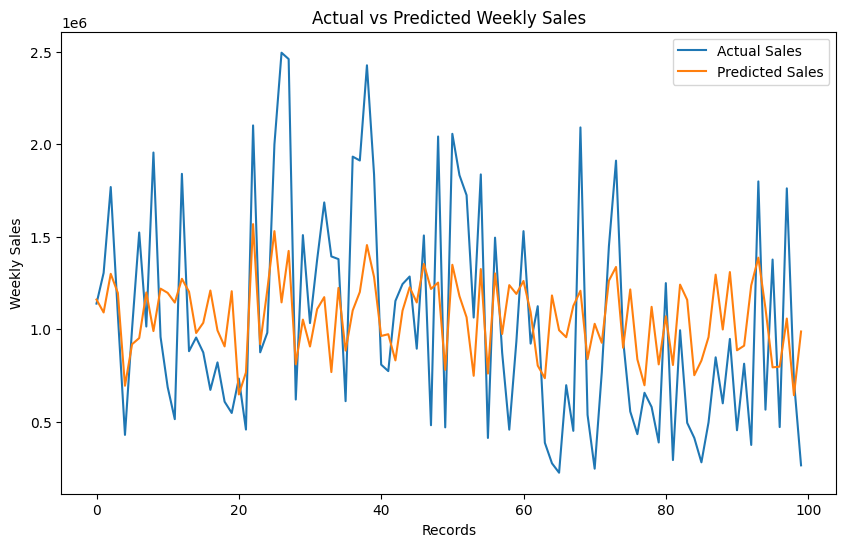

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(y_test.values[:100], label="Actual Sales")
plt.plot(y_pred[:100], label="Predicted Sales")

plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Records")
plt.ylabel("Weekly Sales")
plt.legend()

plt.show()

In [ ]:
import pandas as pd

new_data = pd.DataFrame({
    "Store":[1],
    "Holiday_Flag":[0],
    "Temperature":[70],
    "Fuel_Price":[3.5],
    "CPI":[220],
    "Unemployment":[7.0],
    "Day":[15],
    "Month":[7],
    "Year":[2012]
})

prediction = model.predict(new_data)

print("Predicted Weekly Sales:", prediction[0])

Predicted Weekly Sales: 1272939.957988754
